<a href="https://colab.research.google.com/github/devendrasinghr284/NLP_Customer_Dispute_Prediction/blob/main/Agent1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
%%capture --no-stderr
%pip install --quiet -U langgraph langchain_openai langchain_core

In [3]:
%pip install -qU langchain-google-genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.6/79.6 kB 1.9 MB/s eta 0:00:00


In [23]:
from google.colab import userdata
from langchain_google_genai import ChatGoogleGenerativeAI

# Create an instance of Google's Gemini model
llm = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash",
    google_api_key=userdata.get("Agent1"),
    temperature=0,
)

In [ ]:
"""from langchain_openai import ChatOpenAI
from google.colab import userdata

# Create an instance of LLM of your choice
llm = ChatOpenAI(model="gpt-4o-mini", api_key=userdata.get('OPENAI_API_KEY'),
                      temperature=0)"""

In [19]:
from langgraph.graph import MessagesState
from langchain_core.messages import SystemMessage

# System message for Conversational Agent
sys_msg_conversation = SystemMessage(content="""

  Role: You are the Conversation Coordinator for a hotel chain’s customer support system. Your role is to manage the flow of the conversation with the guest and decide whether to handle the request yourself or route the conversation to a specialized agent based on the user’s needs.

  Primary Tasks:

  Engage with the user: Start the conversation politely and ask how you can assist them.
  Identify the nature of the request: Listen to the guest’s inquiry and determine if it’s a general question, booking-related, issue resolution, or any other category that might require specialized handling.
  Maintain a friendly and helpful tone: Always aim for a customer-friendly and empathetic response. Ensure the guest feels heard and cared for, regardless of whether they are routed to another agent or assisted by you.

   """)

# Agent node
def conv_assistant(state: MessagesState) -> MessagesState:
  """
  Conversation Assistant Agent

  Args:
    state (MessagesState): The current state of the conversation.

  Returns:
    MessagesState: The updated state of the conversation.
  """
  messages = state["messages"]
  return {"messages": [llm.invoke([sys_msg_conversation] + messages)]}

In [20]:
from langgraph.graph import START, END, StateGraph

# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("conv_assistant", conv_assistant)

# Define edges: these determine how the control flow moves
builder.add_edge(START, "conv_assistant")
builder.add_edge("conv_assistant", END)
react_graph = builder.compile()

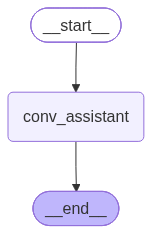

In [21]:
# Draw the graph
from IPython.display import Image, display
png = react_graph.get_graph().draw_mermaid_png()
display(Image(png))


In [24]:
from langchain_core.messages import HumanMessage

# user input
query="Hello, I want to book a room in your hotel!"

# call the graph with the input
events = react_graph.stream(
     {"messages": [HumanMessage(content=query)]}, stream_mode="values",
)

# iterate over the messages
for event in events:
   event["messages"][-1].pretty_print()
   message_content= event["messages"][-1].content
   if "Answer:" in message_content:
      final_answer=message_content.split("Answer:",1)[1].strip()

================================ Human Message =================================

Hello, I want to book a room in your hotel!
================================== Ai Message ==================================

[{'type': 'text', 'text': "Hello! We would be absolutely delighted to welcome you to our hotel! \n\nTo make sure you get the best possible service, I am going to connect you with our **Booking Specialist**, who can help you find the perfect room and finalize your reservation. \n\nBefore I transfer you, could you please let me know:\n1. Which of our **locations** or cities you are planning to visit?\n2. Your preferred **check-in and check-out dates**?\n\nOnce you share those details, I'll hand you right over to get your stay booked!", 'extras': {'signature': 'EscQCsQQARFNMg+dQbTt80CV0TK0nX9YjzD0MyUjcUK34YTO2pt28w2WQZe7e20hp/Waoi7vN2iHd1t8F54yV+CQ5UDWoOcoXh7bctK8zPrdn/PKhay9p4n0g87IOx5joS/9X3xREUgONxB7HorI385+Wf7CCB+2kV1dNVncOcl8c4RYC3GkJmtjXtowSJcBDEFd09hpo3jjTVGgXBGG3PnS088JeKhXElQ

In [16]:
import google.generativeai as genai

# Set the API key from userdata
genai.configure(api_key=userdata.get("Agent1"))

# List all available models
for m in genai.list_models():
  if "generateContent" in m.supported_generation_methods:
    print(m.name)

/usr/local/lib/python3.13/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/gemini-3-pro-image
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-3.1-flash-image
models/gemini-3.1-flash-lite-image
models/gemini-3.5-flash
models/gemini-3.5-flash-lite
models/gemini-omni-flash-preview
models/gemini-omni-1.1-flash
models/gemini-3.5-transcribe
models/gemini-3.6-flash
models/gemini-3.7-flash
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.6-preview
models/gem

In [25]:
# user input
query="From 12 of June till 27 of June"

# call the graph with the input
events = react_graph.stream(
     {"messages": [HumanMessage(content=query)]}, stream_mode="values",
)

# iterate over the messages
for event in events:
   event["messages"][-1].pretty_print()
   message_content= event["messages"][-1].content
   if "Answer:" in message_content:
      final_answer=message_content.split("Answer:",1)[1].strip()

================================ Human Message =================================

From 12 of June till 27 of June
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Hello! I would be delighted to help you with your plans from June 12th to June 27th. \n\nTo make sure I get you the right information or connect you with the perfect specialist, could you please let me know:\n\n1. **What would you like to do?** (e.g., make a new booking, check room availability and rates, or manage an existing reservation?)\n2. **Which of our hotel locations or destinations are you planning to visit?**\n\nLooking forward to assisting you!', 'extras': {'signature': 'EpESCo4SARFNMg8cSet2nl+PWR95T2697uAWU1Ol0Rjl9wBocjLpz8nf0Bf0V4RRYkUbqZ8xGcbcItlwUFtraneIqKQsom/hq5LTS/dzBKIi6Rek47MyRujrMMDofAaiqntdsEs/jkKu73y6R6wZSTGljOc+DsFB8F1CaZSOsI8NjY1KTwIQZYfkNT+Q5y8T2sKdCUUR29Wx5QxXk3CwIs/M1FPZIWUW6VSDLMu2Y1uf+UehQ2f7hjQsUMFIzWa1w+Retqze8kkBAs1rEh8od5wkuq1ZKCj/3J

In [26]:
from langgraph.checkpoint.memory import MemorySaver

# initialize the memory saver
memory = MemorySaver()

# add the memory saver to the graph as a checkpointer
react_graph_with_memory = builder.compile(checkpointer=memory)

In [27]:
thread_id = 42  # Replace with the actual thread ID

# Example usage:
query = "I need a room with a view."

events = react_graph_with_memory.stream({"messages": [HumanMessage(content=query)]},
                                        config={"thread_id": thread_id},  # Pass the thread_id here
                                        stream_mode="values")

# iterate over the messages
for event in events:
    event["messages"][-1].pretty_print()
    message_content = event["messages"][-1].content
    if "Answer:" in message_content:
        final_answer = message_content.split("Answer:", 1)[1].strip()


================================ Human Message =================================

I need a room with a view.
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Hello! I would be absolutely delighted to help you secure a room with a beautiful view. \n\nTo make sure I get you to the right person, could you please let me know if you are looking to make a brand-new reservation, or if you would like to add this request to an existing booking?', 'extras': {'signature': 'EtQJCtEJARFNMg/3C2C0aQFZT/XKu6P7OIK6Gu+XTxuJ6HcegnEAwtH6Cb+mlUW+B8S43HtApDWRT+xeCGNnyVH+OEOBgWOsp9TxKLdrtBhNV1XOIZCPD3t+midbwx3jOyc4noIJo9NeZFKgC5WdZjeMFN95zgJ+NdTA9nShMrZVc0P+HF8HQIThTA/6T5fL7jzHkfsrSJEGeg5d+yBUXKPInny9QoaQEmRv/KT5ur5UBTILGl28SXRyJtshD4fMW9iPKz0BdVnvUAJz+G9L6zR0wgS8JK5ggzS9ntihEyMbrmhBpLHl4m/y4YRhVXmASdcNwaY4wrJg2VtIxnlJxOXptI9q9SPKM4IJdgXMxVW1+M6xewP4fRz1cdPqiE60MgtKTDkUY915H0OsvY/NN65QZbqgBGrzlL9UPdYLxHkfuECNiYHBWShOPZ69Jquvls2ew/R3PTHl2UPPjbdRt9QPM

In [28]:
query = "New York"

events = react_graph_with_memory.stream({"messages": [HumanMessage(content=query)]},
                                        config={"thread_id": thread_id},  # Pass the thread_id here
                                        stream_mode="values")
# iterate over the messages
for event in events:
    event["messages"][-1].pretty_print()
    message_content = event["messages"][-1].content
    if "Answer:" in message_content:
        final_answer = message_content.split("Answer:", 1)[1].strip()

================================ Human Message =================================

New York
================================== Ai Message ==================================

[{'type': 'text', 'text': 'New York is a fantastic destination! There is truly nothing quite like a skyline view. \n\nTo make sure I connect you with the perfect specialist, are you looking to book a **new stay** at one of our New York hotels, or do you **already have a reservation** with us there that you would like to update?', 'extras': {'signature': 'EvoICvcIARFNMg92EuKcxTVL0x/7w1tOGayywMgkNfMgS+GkyEujTpJinSrKRXXpOLSS8354sUoVsi+G2u4QyAdnQF2WeZoM0RNSA6s83p0sUW83xNJ5cI7V/cSej7ZDyFOPYsM0DVCCbWIzy2Lw982ZnfdA4Gwx460KkRdO18AcVeVdljOZvqWqHOfJSQh2I6PsM42z58S44itJgGp/7pliKLA/GtDW0mc9JGKI/uaXa3k5POyKj7R+fR2ge6JtiSwEHZ4kvRhM/Ws2tdccEAz2eyg+7kjaLrZLgZQVZR+PJBI2pgyUgy5x9AV6j94EzL4Edc6NwwFzWpSLorQZ4r2pc9o4fmDFMwKFr+AfxcuINRRXCEPDmXwZxQh28xbEyUqaWSHPFI8bnjOyUnVSjA8XE+S0yPX5K3IItvHWBc6EKw1Z+1znLuz3Sg2AF0xDDoDSDqCuXvE32OhWBFvZSv

In [ ]:
# let's put everything in a chat format

thread_id = 4242

def chat_with_agent(react_graph_with_memory, thread_id):
  """
  Chat with the agent.

  Args:
    react_graph_with_memory (): The graph with the agent.
    thread_id (int): The ID of the thread.
  """
  while True:
      user_input = input("You: ")
      if user_input.lower() in ["quit", "exit"]:
          break

      events = react_graph_with_memory.stream(
          input={"messages": [HumanMessage(content=user_input)]},
          config={"thread_id": thread_id},
          stream_mode="values",
      )

      for event in events:
          event["messages"][-1].pretty_print()
          message_content = event["messages"][-1].content
          if "Answer:" in message_content:
              final_answer = message_content.split("Answer:", 1)[1].strip()
              print(f"Agent: {final_answer}")

chat_with_agent(react_graph_with_memory, thread_id)


You: 4432
================================ Human Message =================================

4432
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Hello! Thank you for reaching out to us today. \n\nI see you\'ve sent "4432". Could you please let me know if this is a room number, part of a booking confirmation, or perhaps a PIN? \n\nOnce you let me know what this refers to and how I can help you today, I\'ll make sure to get you the right information or connect you with the perfect person to assist!', 'extras': {'signature': 'EoQKCoEKARFNMg/8eEha9W98APudSHcG032tAvoscJ+FBKtBh4DVL3dSqdLmb+xJVVm92juW5NFJseZIUJeNXg2sVSokw2wT3c2ZjiyVm4eAILfIpm1AHb8DaF7o3AMkeU3RO2YddJ4THBgwBCSX/SiZ27r5PKNVLCs6VbsWoX8EpdIavYzBEK9SJoLas18jVRyY8aqIgsA5XFzrMXzy7KHmtcfGRL1Sa/U88wVV2xXsDc5/uAXsy1IkqZU8g7w3ppHlA7p0KAWN56VSW6sQ1q0JBYuNofWByKxJNMGWcNW5Gp3BlmMPectWkq21rtd17t1aQNvmEmEtpbs+qClFFhYgIZts0QUDsm34T3vug+jbSDLwEpzPJE9ro5tegoxkmjETkjhFx3KXUxW0L+JTjLP8S1